In [2]:
# dataset @NABIL from Nepal Stock Exchange through ShareSansar

In [3]:
#importing pandas which is used to read data
import pandas as pd

In [4]:
df = pd.read_csv("NABIL.csv")

In [5]:
# Displaying the date and closing price of that date
df = df[['Date','Close']]
df

,Date,Close
0,3/20/2011,1170.0
1,3/24/2011,1153.0
2,3/25/2011,1174.0
3,3/27/2011,1147.0
4,3/28/2011,1132.0
...,...,...
3120,12/1/2024,536.0
3121,12/2/2024,534.0
3122,12/3/2024,532.0
3123,12/4/2024,530.0


In [6]:
df['Date']

0       3/20/2011
1       3/24/2011
2       3/25/2011
3       3/27/2011
4       3/28/2011
          ...    
3120    12/1/2024
3121    12/2/2024
3122    12/3/2024
3123    12/4/2024
3124    12/5/2024
Name: Date, Length: 3125, dtype: object

In [7]:
#since date is object datatype, we have to convert it into datetime
import datetime
def str_to_datetime(s):
    split = s.split('/')
    year, month, day = int(split[2]), int(split[0]), int(split[1])
    return datetime.datetime(year = year, month = month, day = day)


In [8]:
#Applying str_to_datetime to each and every date values
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

0      2011-03-20
1      2011-03-24
2      2011-03-25
3      2011-03-27
4      2011-03-28
          ...    
3120   2024-12-01
3121   2024-12-02
3122   2024-12-03
3123   2024-12-04
3124   2024-12-05
Name: Date, Length: 3125, dtype: datetime64[ns]

In [9]:
# We have to now convert the date into index, since date will be related to that date
df.index = df.pop('Date')
df

,Close
Date,
2011-03-20,1170.0
2011-03-24,1153.0
2011-03-25,1174.0
2011-03-27,1147.0
2011-03-28,1132.0
...,...
2024-12-01,536.0
2024-12-02,534.0
2024-12-03,532.0


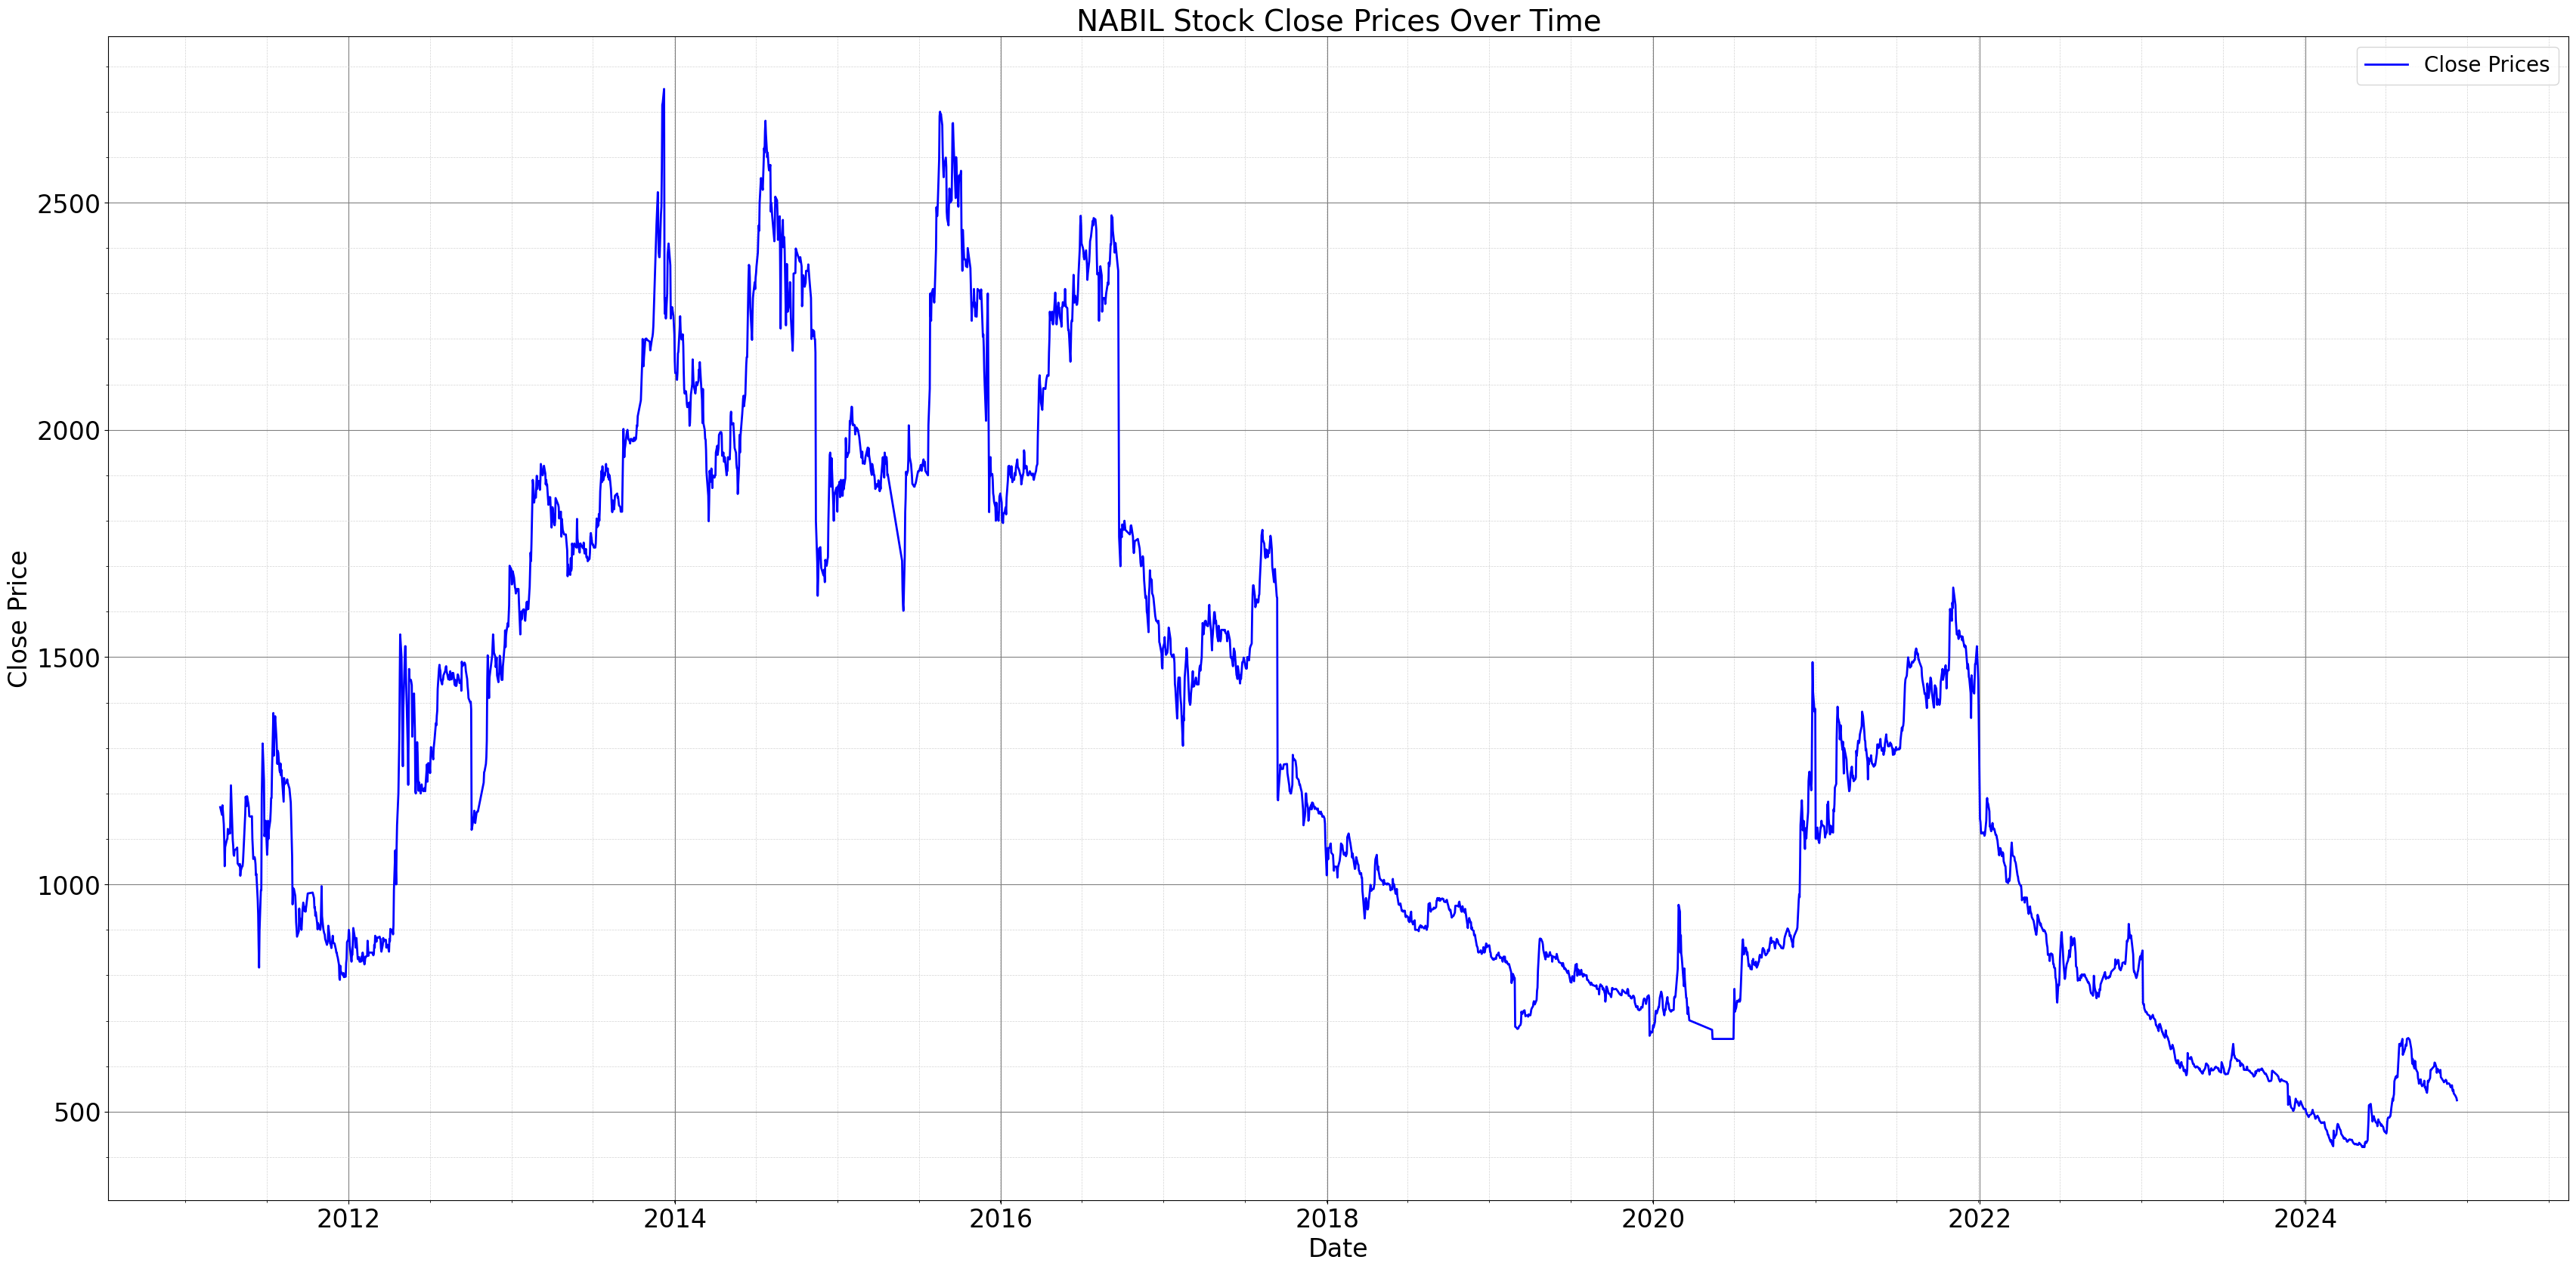

In [10]:
import matplotlib.pyplot as plt

# Set a large figure size
plt.figure(figsize=(42, 20))

# Plot the data
plt.plot(df.index, df['Close'], label="Close Prices", color='blue', linewidth=2)

# Add labels, title, and legend
plt.xlabel("Date", fontsize=24)
plt.ylabel("Close Price", fontsize=24)
plt.title("NABIL Stock Prices Over Time", fontsize=28)
plt.legend(fontsize=20)

# Increase tick label size
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)

# Enable minor ticks for a denser grid
plt.minorticks_on()

# Add both major and minor gridlines
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.8)  # Major gridlines
plt.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.5)  # Minor gridlines

# Show the plot
plt.show()



In [11]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np


In [12]:
scaler = MinMaxScaler(feature_range= (0,1))
data_scaled = scaler.fit_transform(df)
data_scaled


array([[0.32130584],
       [0.31400344],
       [0.32302405],
       ...,
       [0.04725086],
       [0.04639175],
       [0.04424399]])

In [13]:
#Create windowed dataset
def create_windowed_data(df, window_size):
    x,y = [], []
    for i in range(window_size, len(df)):
        x.append(df[i-window_size:i, 0])
        y.append(df[i, 0])
    return np.array(x), np.array(y)


In [14]:
# Hyperparameters
window_size = 60

In [15]:
# Prepare training and testing datasets
training_size = int(len(data_scaled)*0.80)
test_size = len(data_scaled)- training_size
train_data, test_data = data_scaled[0:training_size,:], data_scaled[training_size: len(data_scaled),:1]
x_train, y_train = create_windowed_data(train_data, window_size)
x_test, y_test = create_windowed_data(test_data, window_size)

In [16]:
# Reshape data for LSTM input (samples, timesteps to look back, features)
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1],1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [18]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
#Train the model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32, verbose=1)